In [ ]:
import emcee
import numpy as np
import matplotlib.pyplot as plt
import corner
import dynesty
from dynesty import plotting as dyplot

THE TRANSIENT UNIVERSE WITH NESTED SAMPLING

In [2]:
#first column is time, second column is flux and the third column is the error on the flux (homoskedastic errors)
data = np.load("transient.npy")

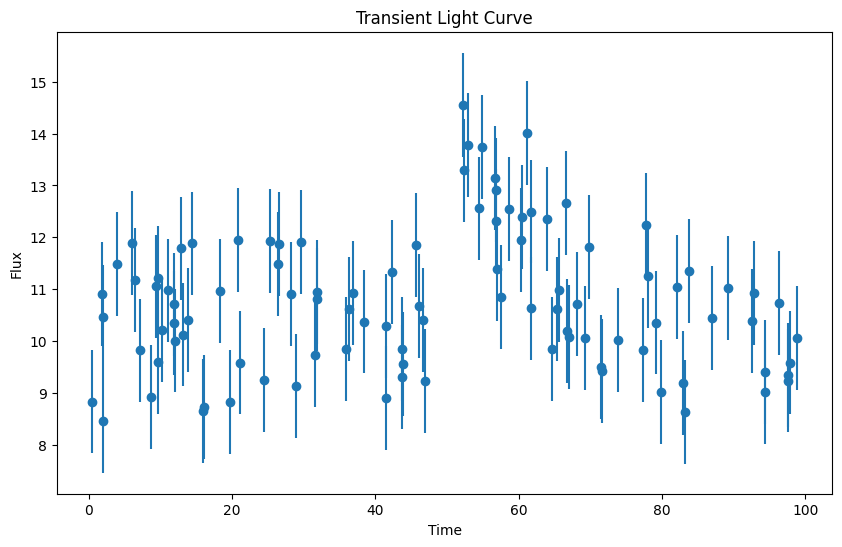

In [3]:
#make a plot of the data with error bars
plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o')
plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Transient Light Curve")
plt.show()  

In [4]:
# The model has 4 parameters: the time of the burst t0, the amplitude of the burst A, the decay time of the burst alphaand the background amplitude B

def Model(t, t0, A, alpha, B):
    # Clip the math inside the exponent so it doesn't blow up to infinity
    arg = -(t - t0) * alpha
    safe_arg = np.clip(arg, -700, 700) #it did't work without clipping ( or even for -1000,1000).
    
    return A * np.exp(safe_arg) * (t >= t0) + B

# Define log-likelihood that take in input the array parameters of the model and the array of data 
def Log_Likelihood(theta, data):
    t0, A, alpha, B = theta
    t=data[:,0]
    y=data[:,1]
    yerr=data[:,2]
    model_flux = Model(t, t0, A, alpha, B)
    return -0.5 * np.sum(((y - model_flux) / yerr) ** 2)

# Define a prior on the parameters of the model. We assume that the parameters are uniformly distributed in a reasonable range.
#alpha is uniform in log space, so the prior on alpha is proportional to 1/alpha, which means that the log-prior is -log(alpha)
def Log_Prior(theta):
    t0, A, alpha, B = theta
    
    if (alpha > 0) and (np.min(data[:,0]) < t0 < np.max(data[:,0])) and (0 < A < 50) and (0 < B < 50):
        
        ln_alpha = np.log(alpha)
        if -5 < ln_alpha < 5:
            return -ln_alpha  # This is the log of (1/alpha)
            
    return -np.inf

# Define the prior transform function for nested sampling (since nested sampling works in the unitary cube)
def Prior_Transform(u): 
    # u is an array of 4 random numbers between 0 and 1
    u_t0, u_A, u_alpha, u_B = u
    
    # t0: Uniform between min(time) and max(time)
    t0 = u_t0 * (np.max(data[:,0]) - np.min(data[:,0])) + np.min(data[:,0])
    
    # A: Uniform between 0 and 50
    A = u_A * (50.0 - 0.0)
    
    # Alpha: Log-Uniform between e^-5 and e^5
    ln_alpha = u_alpha * (5 - (-5)) + (-5)
    alpha = np.exp(ln_alpha)
    
    # B: Uniform between 0 and 50
    B = u_B * (50.0 - 0.0)
    
    return np.array([t0, A, alpha, B])

def Log_Posterior(theta, data):
    return Log_Prior(theta) + Log_Likelihood(theta, data)

In [18]:
#use nested sampling to sample the posterior distribution of the parameters of the model, using the dynesty package.
ndim = 4  # number of parameters
nlive = 1000  # number of live points
sampler = dynesty.NestedSampler(Log_Likelihood, Prior_Transform, ndim, logl_args=[data], nlive=nlive)
sampler.run_nested()
sresults = sampler.results






8085it [01:15,  2.50it/s, bound: 92 | nc: 505 | ncall: 137015 | eff(%):  5.901 | loglstar:   -inf < -86.543 <    inf | logz: -93.497 +/-  0.077 | dlogz: 36.022 >  1.009]     /Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
8096it [01:17,  6.45it/s, bound: 94 | nc: 275 | ncall: 141695 | eff(%):  5.714 | loglstar:   -inf < -86.499 <    inf | logz: -93.493 +/-  0.077 | dlogz: 36.007 >  1.009] /Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and M

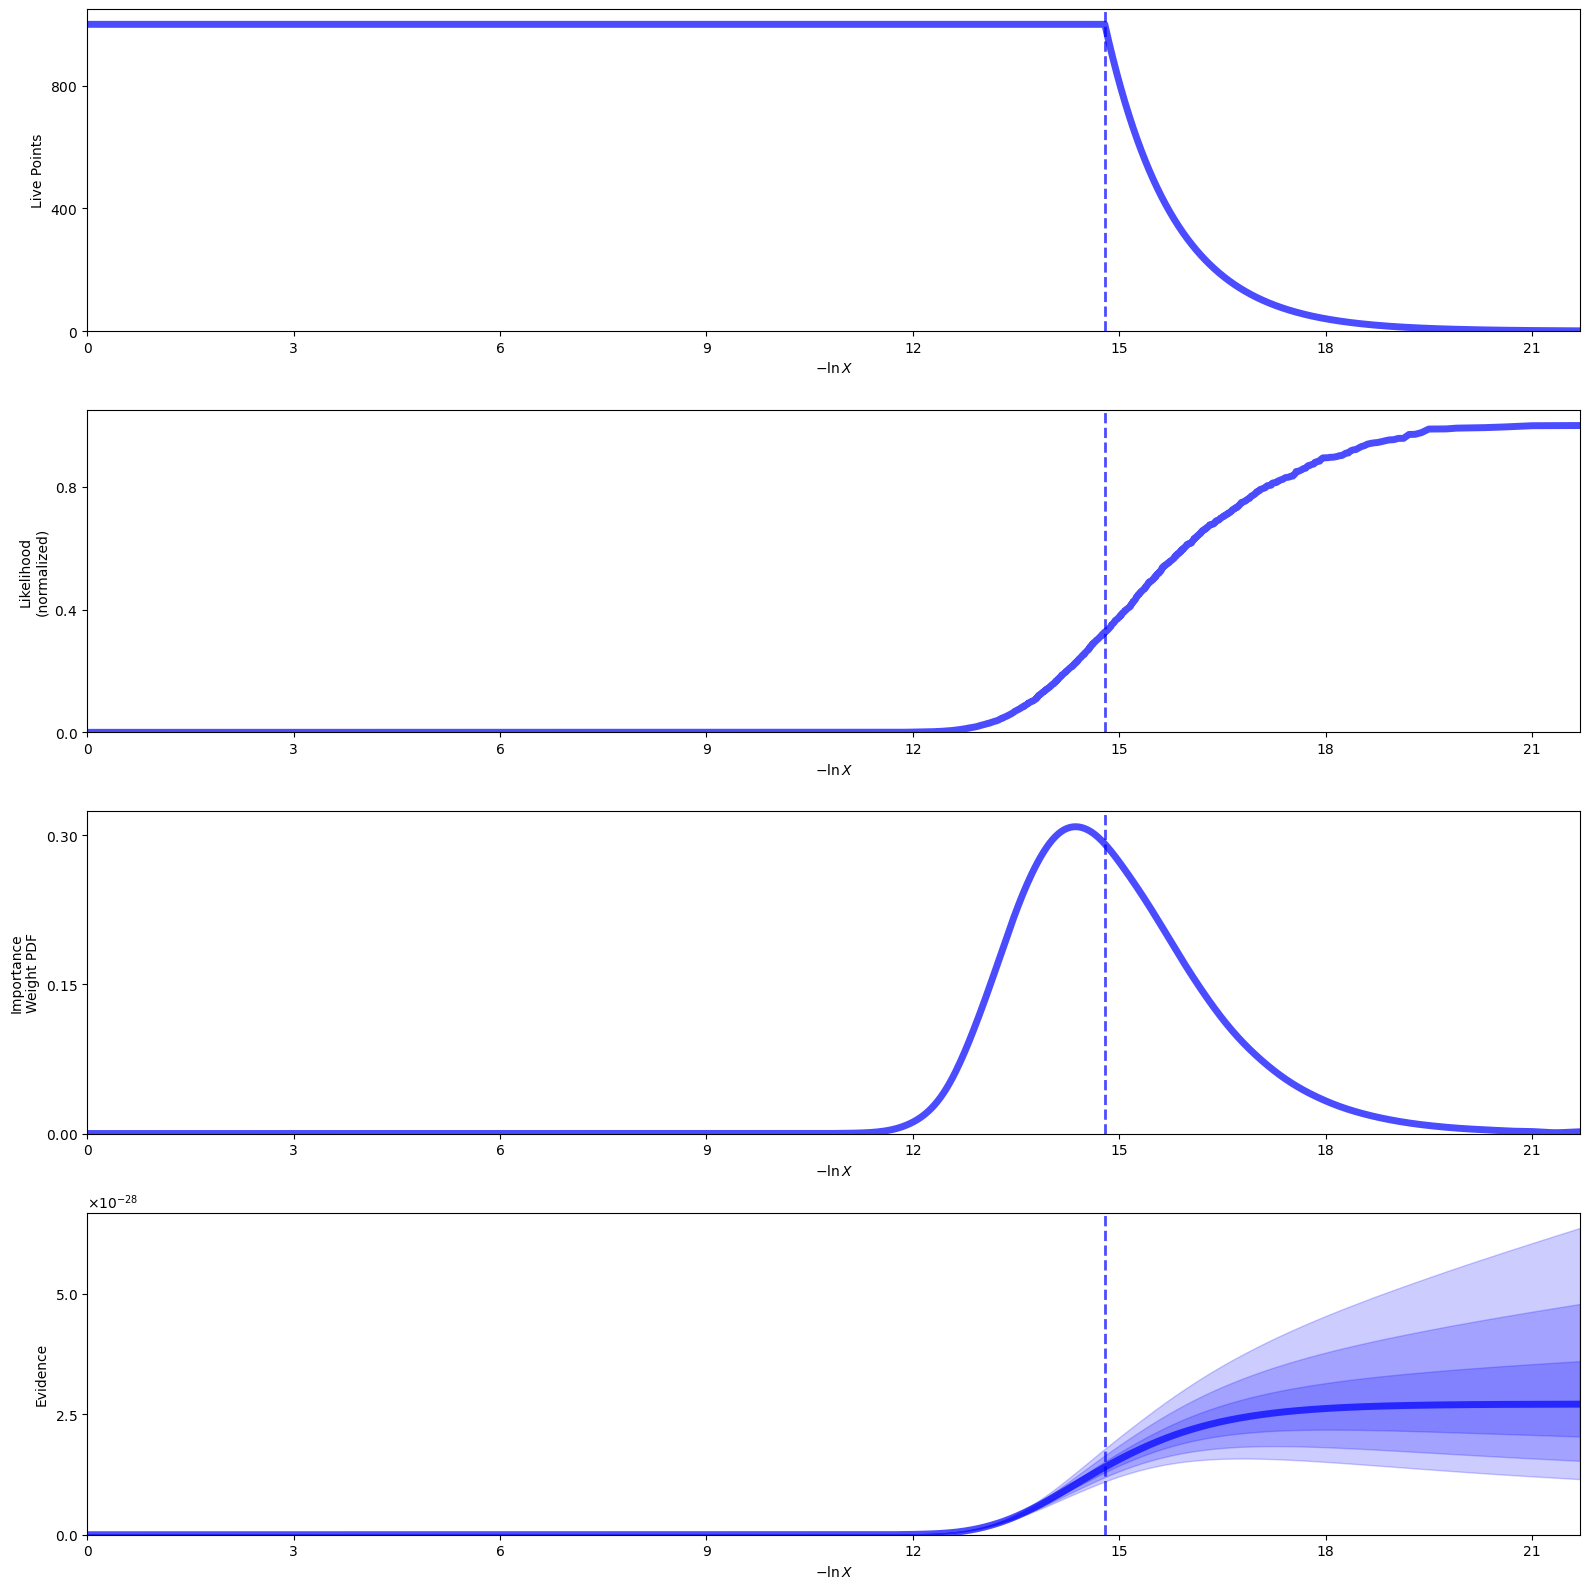

In [20]:
#plot a summary ot the run
rfig, raxes = dyplot.runplot(sresults)
plt.tight_layout()
plt.show()

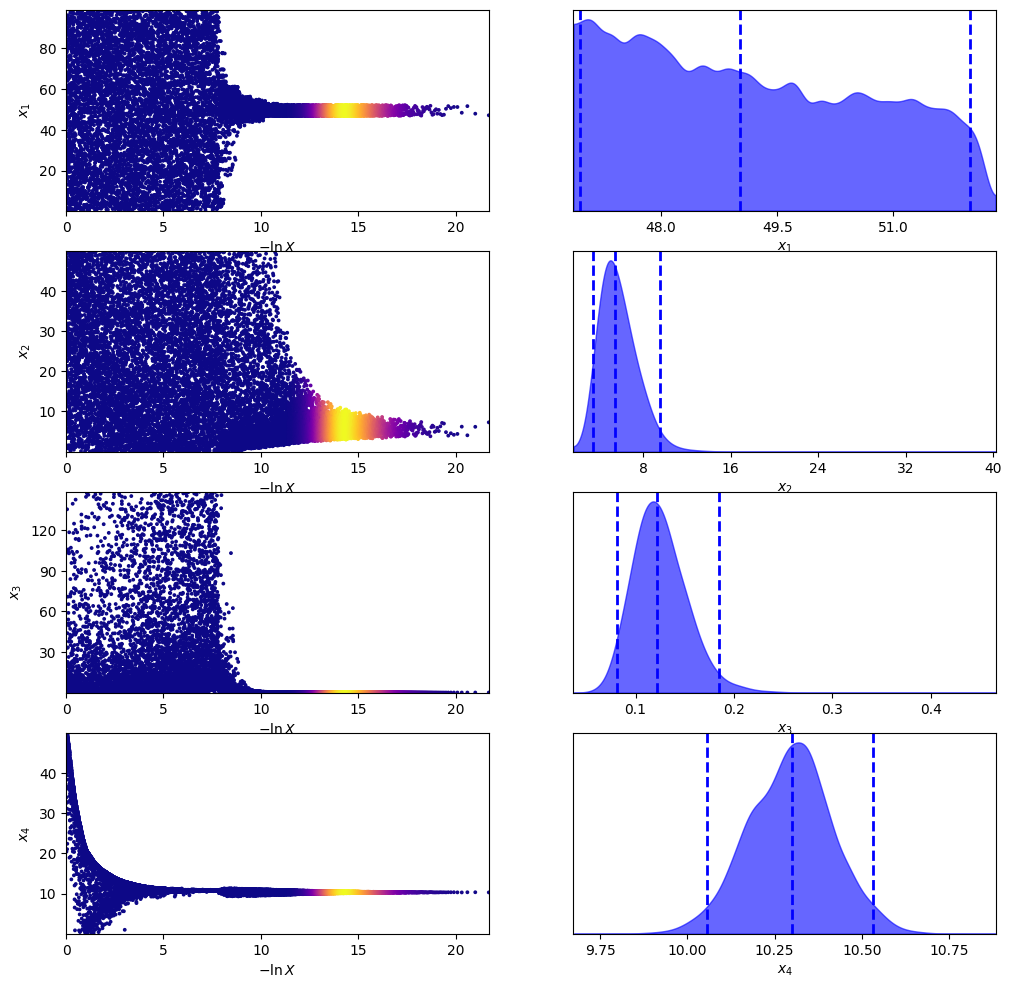

In [21]:
# plot the trace of the parameters of the model as a function of the iteration number, to check for convergence
tfig, taxes = dyplot.traceplot(sresults)

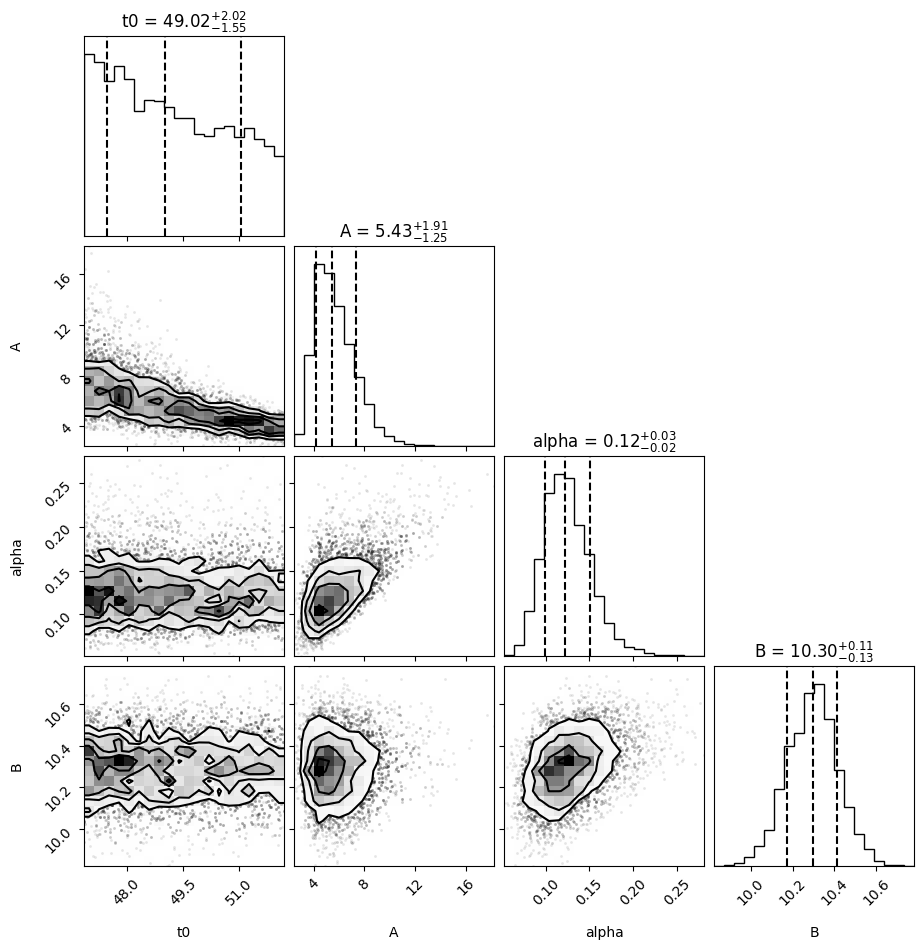

In [23]:
# plot the corner plot of the posterior distribution of the parameters of the model, using the corner package.
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["A","b","t0","alpha"]

samples_equal = dynesty.utils.resample_equal(samples, weights)
fig = corner.corner(samples_equal, labels=["t0", "A", "alpha", "B"], show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12})
plt.show()  

In [26]:
# Print the results
labels = [r"t0", r"A", r"alpha", r"B"]

print("Result (Median + 90% Credible Region):")
print("-" * 40)

for i in range(ndim):
    q_5, q_median, q_95 = dynesty.utils.quantile(samples[:, i], [0.05, 0.5, 0.95], weights=weights)
    
    plus_error = q_95 - q_median
    minus_error = q_median - q_5
    
    print(f"{labels[i]} = {q_median:.4f} +{plus_error:.4f} -{minus_error:.4f}")

print("-" * 40)
sresults.summary()

Result (Median + 90% Credible Region):
----------------------------------------
t0 = 49.0245 +2.7538 -1.9736
A = 5.4266 +3.2449 -1.8354
alpha = 0.1222 +0.0501 -0.0361
B = 10.2991 +0.1948 -0.2021
----------------------------------------
Summary
nlive: 1000
niter: 14797
ncall: 222923
eff(%):  7.086
logz: -63.477 +/-  0.285


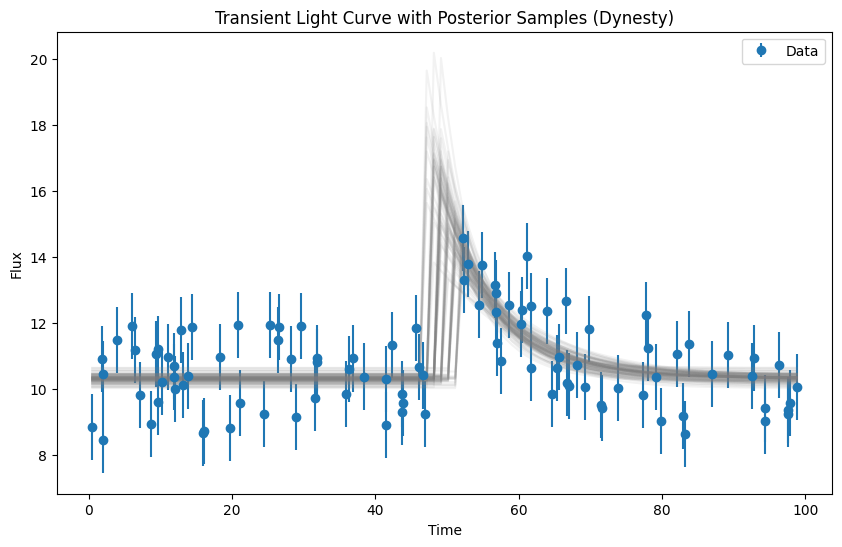

In [29]:
# Choose 100 random samples from the dynesty chain and plot the corresponding burst time series on top of the data to visualize the fit of the model to the data.
plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o', label='Data') 

t_fit = np.linspace(np.min(data[:,0]), np.max(data[:,0]), 100)

for i in range(100):
    sample = samples_equal[np.random.randint(len(samples_equal))] 
    
    t0_sample, A_sample, alpha_sample, B_sample = sample 
    model_flux_sample = Model(t_fit, t0_sample, A_sample, alpha_sample, B_sample)
    
    plt.plot(t_fit, model_flux_sample, color='gray', alpha=0.1)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Transient Light Curve with Posterior Samples (Dynesty)")
plt.legend()
plt.show()

Gaussian model

In [27]:
# Define a new possible model for the data, a Gaussian burst 
def Model_Gaussian(t, t0, A, sigma, B):
    return A * np.exp(-0.5 * ((t - t0) / sigma) ** 2) + B

In [ ]:
# Redefine the log-likelihood and log-prior functions for the new model, which has 4 parameters: t0, A, sigma and B. We assume that the priors on t0, A and B are the same as before, while the prior on sigma is uniform in log space between e^-5 and e^5.

def Log_Likelihood_Gaussian(theta, data):
    t0, A, sigma, B = theta
    t=data[:,0]
    y=data[:,1]
    yerr=data[:,2]
    model_flux = Model_Gaussian(t, t0, A, sigma, B)
    return -0.5 * np.sum(((y - model_flux) / yerr) ** 2)    

def Log_Prior_Gaussian(theta):
    t0, A, sigma, B = theta
    
    if (sigma > 0) and (np.min(data[:,0]) < t0 < np.max(data[:,0])) and (0 < A < 50) and (0 < B < 50):
        
        ln_sigma = np.log(sigma)
        if -2 < ln_sigma < 2:
            return -ln_sigma  # This is the log of (1/sigma)
            
    return -np.inf

def Prior_Transform_Gaussian(u):
    # u is an array of 4 random numbers between 0 and 1
    u_t0, u_A, u_sigma, u_B = u
    
    # t0: Uniform between min(time) and max(time)
    t0 = u_t0 * (np.max(data[:,0]) - np.min(data[:,0])) + np.min(data[:,0])
    
    # A: Uniform between 0 and 50
    A = u_A * 50.0
    
    # sigma: Log-Uniform between e^-2 and e^2
    ln_sigma = u_sigma * (2 - (-2)) + (-2)
    sigma = np.exp(ln_sigma)
    
    # B: Uniform between 0 and 50
    B = u_B * 50.0
    
    return np.array([t0, A, sigma, B])

def Log_Posterior_Gaussian(theta, data):
    return Log_Prior_Gaussian(theta) + Log_Likelihood_Gaussian(theta, data)


In [30]:
# Use nested sampling to sample the posterior distribution of the parameters of the new model, using the dynesty package.
ndim = 4  # number of parameters
nlive = 100  # number of live points
sampler_gaussian = dynesty.NestedSampler(Log_Likelihood_Gaussian, Prior_Transform_Gaussian, ndim, logl_args=[data], nlive=nlive)
sampler_gaussian.run_nested()
sresults_gaussian = sampler_gaussian.results

746it [00:07, 15.64it/s, bound: 83 | nc: 139 | ncall: 17982 | eff(%):  4.149 | loglstar:   -inf < -86.561 <    inf | logz: -93.650 +/-  0.246 | dlogz: 26.472 >  0.109]   /Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine Learning/astrostatistics_bicocca_2025-main/.venv/lib/python3.11/site-packages/dynesty/bounding.py:707: UserWarning: The enlargement factor for the ellipsoidal bounds determined from bootstrapping is very large. If you are using uniform sampling that may mean that the sampling will be inefficient. This may be caused by a very complex posterior shape. You may consider using more livepoints or different sampler (i.e. rslice or rwalk) or alternatively disable bootstrap (bootstrap=0)
  warnings.warn(
807it [00:11, 27.72it/s, bound: 108 | nc: 2 | ncall: 29921 | eff(%):  2.697 | loglstar:   -inf < -81.823 <    inf | logz: -92.014 +/-  0.279 | dlogz: 30.462 >  0.109]  /Users/tommasogrisetti/Desktop/università/Magistrale/Astrostatistic and Machine

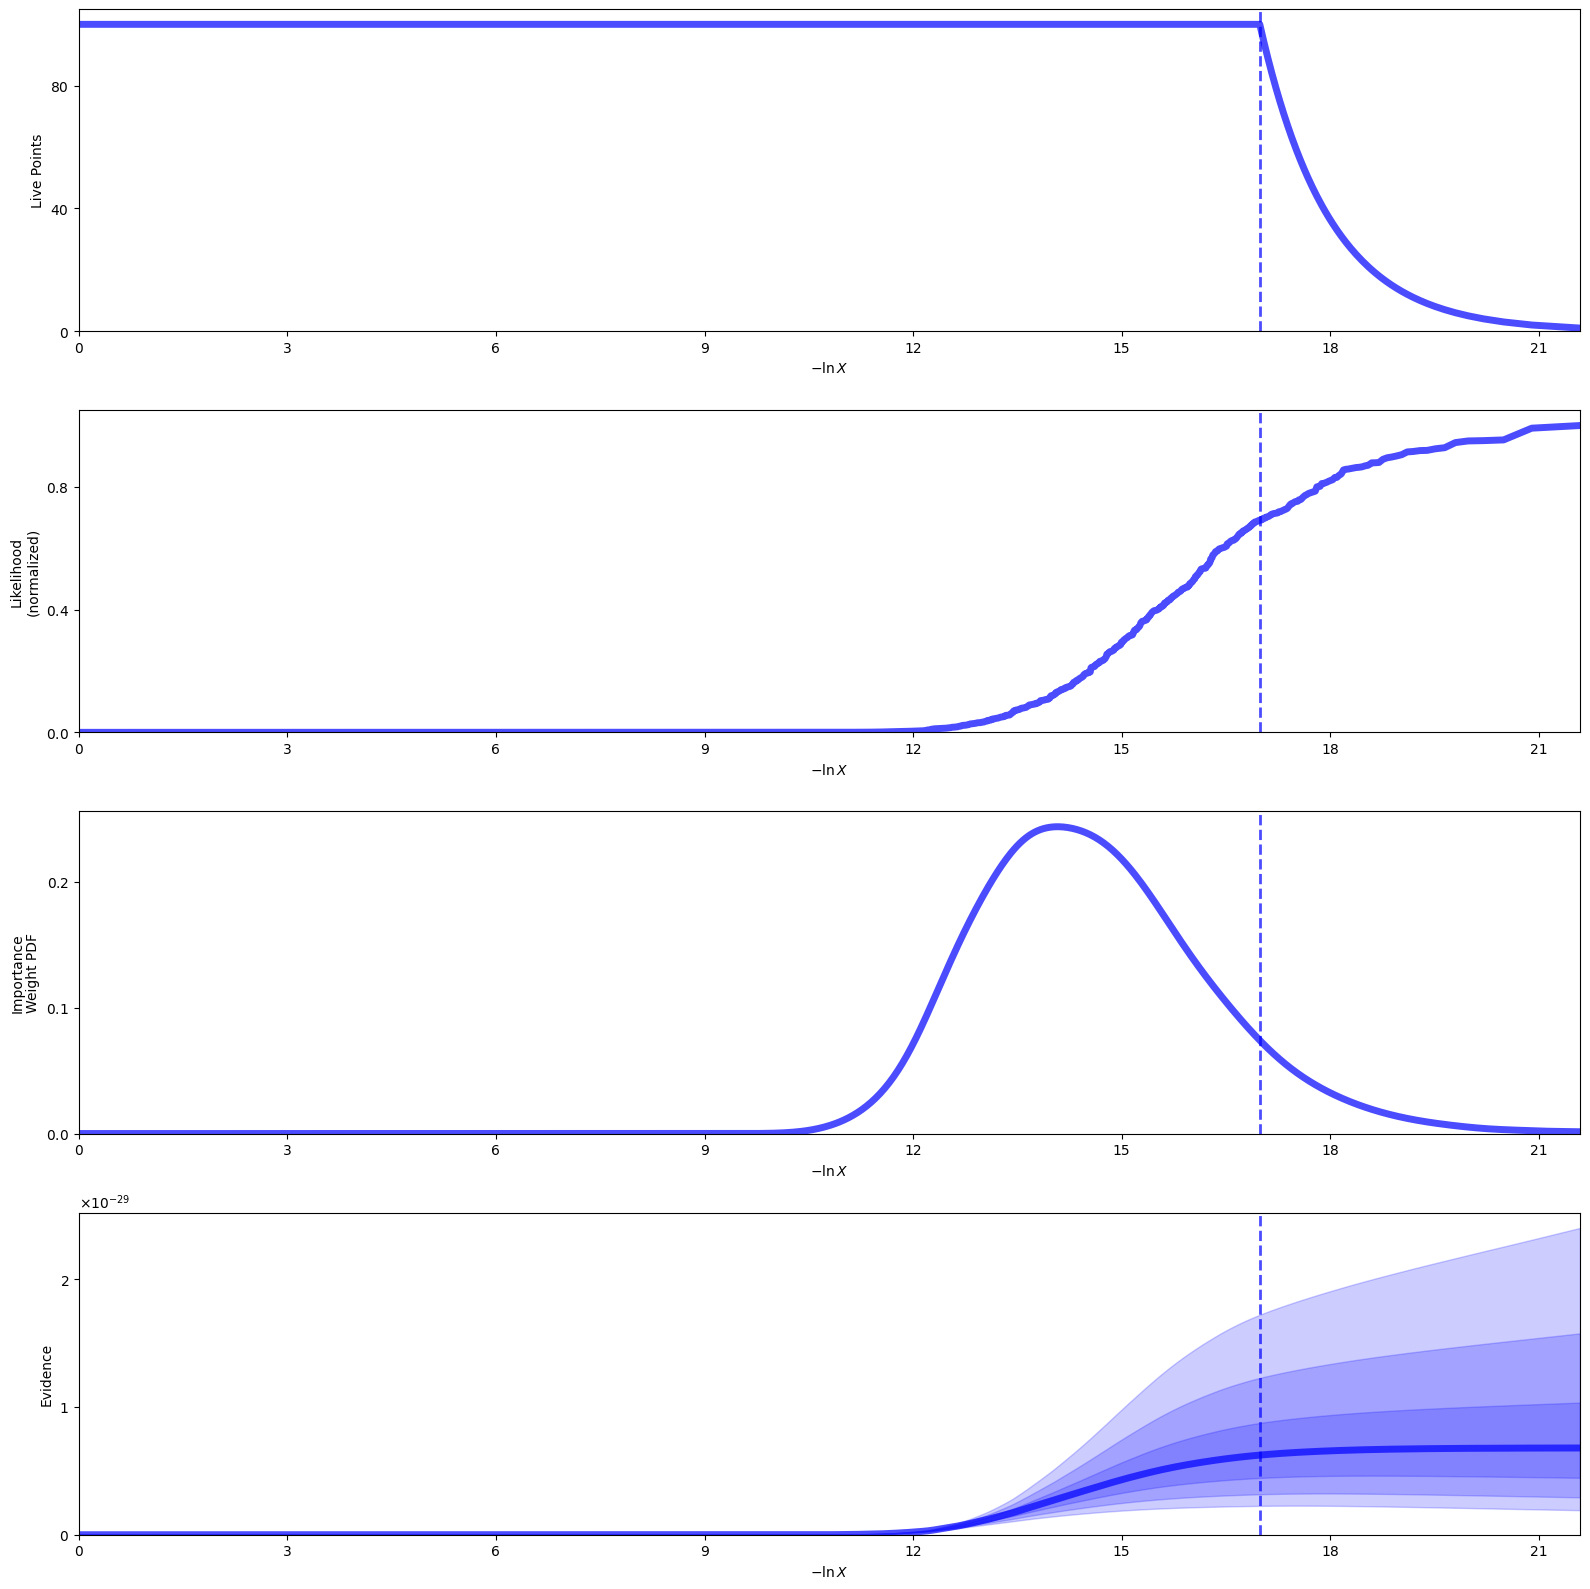

In [31]:
# Plot summary of the run for the Gaussian model
rfig_gaussian, raxes_gaussian = dyplot.runplot(sresults_gaussian)
plt.tight_layout()
plt.show()

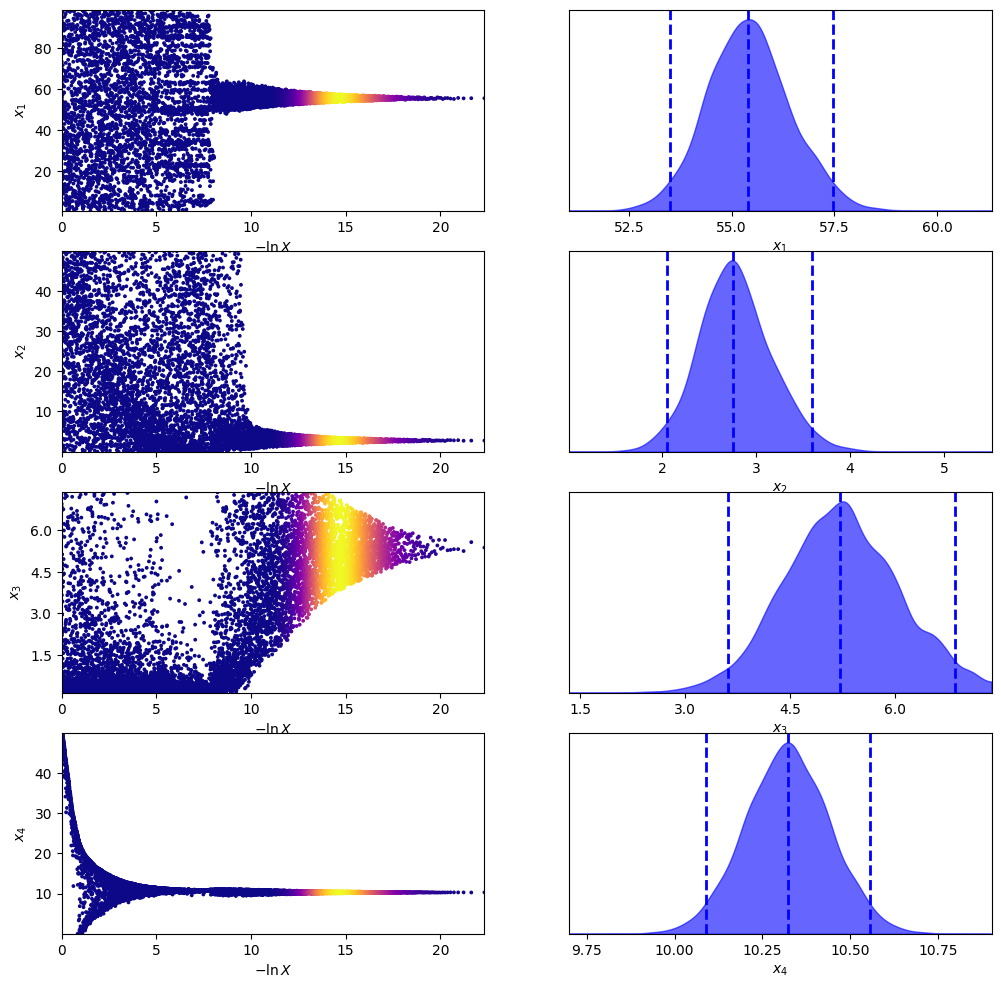

In [ ]:
# Plot the trace for the Gaussian model
tfig_gaussian, taxes_gaussian = dyplot.traceplot(sresults_gaussian)



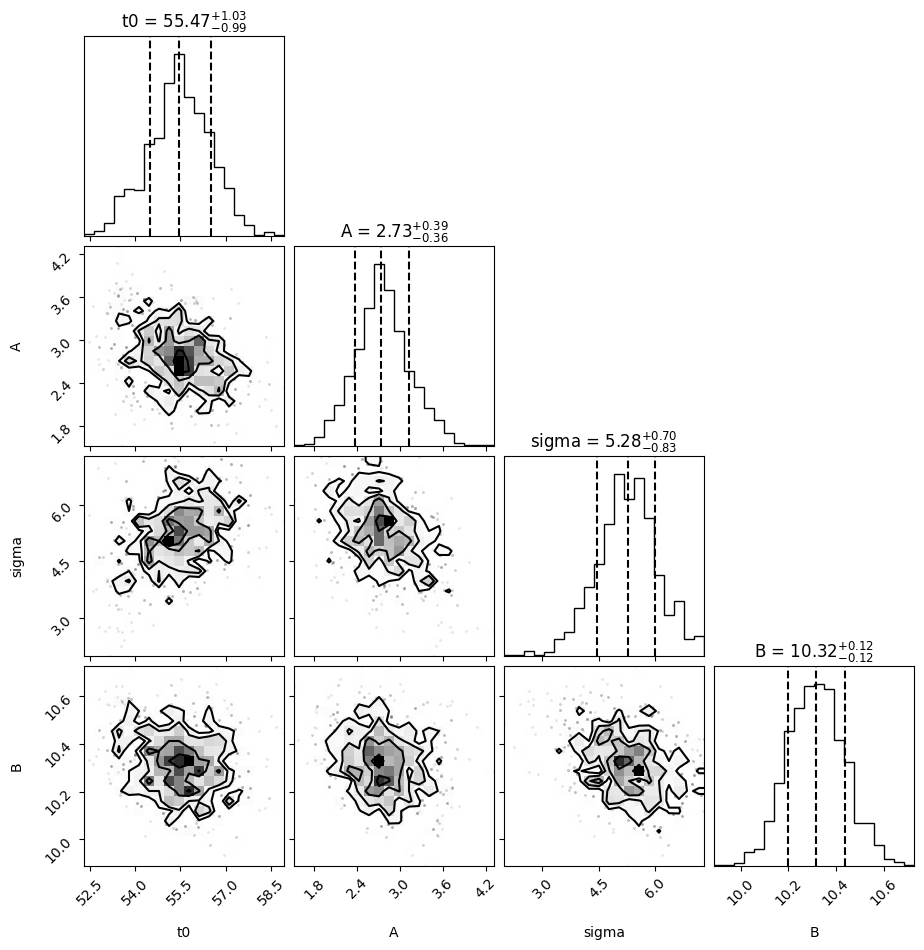

In [33]:
# plot the corner plot of the posterior distribution of the parameters of the model, using the corner package.
samples_gaussian = sresults_gaussian.samples  # samples
weights_gaussian = np.exp(sresults_gaussian.logwt - sresults_gaussian.logz[-1])  # normalized weights

labels = ["A","b","t0","sigma"]

samples_gaussian_equal = dynesty.utils.resample_equal(samples_gaussian, weights_gaussian)
fig = corner.corner(samples_gaussian_equal, labels=["t0", "A", "sigma", "B"], show_titles=True, title_fmt=".2f", quantiles=[0.16, 0.5, 0.84], title_kwargs={"fontsize": 12})
plt.show()  


In [35]:
# Print the results
labels = [r"t0", r"A", r"sigma", r"B"]

print("Result (Median + 90% Credible Region):")
print("-" * 40)

for i in range(ndim):
    q_5, q_median, q_95 = dynesty.utils.quantile(samples_gaussian_equal[:, i], [0.05, 0.5, 0.95])
    
    plus_error = q_95 - q_median
    minus_error = q_median - q_5
    
    print(f"{labels[i]} = {q_median:.4f} +{plus_error:.4f} -{minus_error:.4f}")

print("-" * 40)
sresults.summary()

Result (Median + 90% Credible Region):
----------------------------------------
t0 = 55.4698 +1.6852 -1.7832
A = 2.7346 +0.7051 -0.6101
sigma = 5.2800 +1.3632 -1.3985
B = 10.3174 +0.2040 -0.1823
----------------------------------------
Summary
nlive: 1000
niter: 14797
ncall: 222923
eff(%):  7.086
logz: -63.477 +/-  0.285


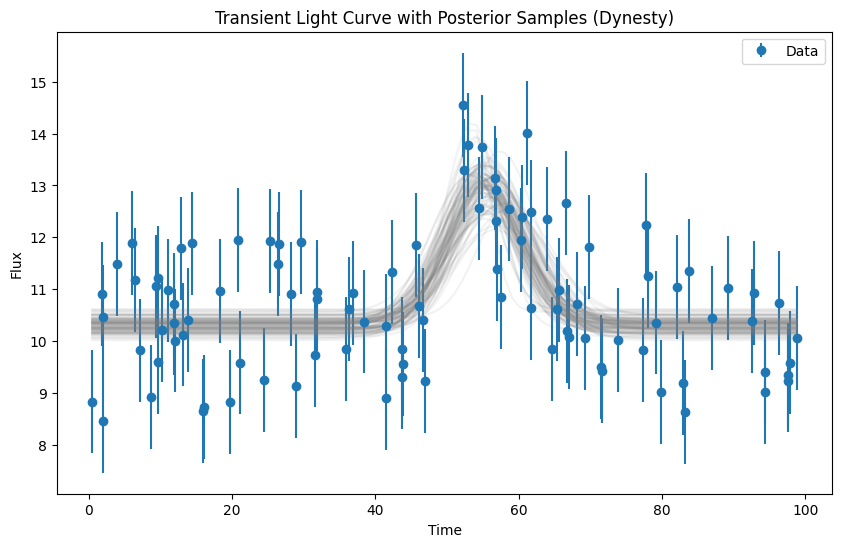

In [37]:
# Choose 100 random samples from the dynesty chain and plot the corresponding burst time series on top of the data to visualize the fit of the model to the data.
plt.figure(figsize=(10,6))
plt.errorbar(data[:,0], data[:,1], yerr=data[:,2], fmt='o', label='Data') 

t_fit = np.linspace(np.min(data[:,0]), np.max(data[:,0]), 100)

for i in range(100):
    sample = samples_gaussian_equal[np.random.randint(len(samples_gaussian_equal))] 
    
    t0_sample, A_sample, sigma_sample, B_sample = sample 
    model_flux_sample = Model_Gaussian(t_fit, t0_sample, A_sample, sigma_sample, B_sample)
    
    plt.plot(t_fit, model_flux_sample, color='gray', alpha=0.1)

plt.xlabel("Time")
plt.ylabel("Flux")
plt.title("Transient Light Curve with Posterior Samples (Dynesty)")
plt.legend()
plt.show()

In [38]:
# Compare the two models using the Bayesian evidence.
# Evidence for the exponential model
logZ_exponential = sresults.logz[-1]
# Evidence for the Gaussian model
logZ_gaussian = sresults_gaussian.logz[-1]

# Bayesian evidence ratio (Bayes factor)
bayes_factor = np.exp(logZ_exponential - logZ_gaussian)
print(f"Log Evidence for Exponential Model: {logZ_exponential:.2f}")
print(f"Log Evidence for Gaussian Model: {logZ_gaussian:.2f}")
print(f"Bayes Factor (Exponential vs Gaussian): {bayes_factor:.2f}")

# Interpret the Bayes factor using the Jeffreys scale:
if bayes_factor < 1:
    print("The Gaussian model is favored over the Exponential model.")
elif bayes_factor < 3:
    print("The evidence in favor of the Exponential model is not strong.")
elif bayes_factor < 10:
    print("The Exponential model is favored over the Gaussian model.")
else:
    print("The Exponential model is strongly favored over the Gaussian model.")
    

Log Evidence for Exponential Model: -63.48
Log Evidence for Gaussian Model: -67.16
Bayes Factor (Exponential vs Gaussian): 39.88
The Exponential model is strongly favored over the Gaussian model.
